Hands-On Lab: Sprint 3 Close-Out        
● Step 1: Produce the full evaluation for the project with the correct metrics, reported against the Week 6 baseline.       
● Step 2: If the task is imbalanced, apply SMOTE or threshold tuning and report the precision-recall tradeoff.        
● Step 3: Generate SHAP global feature importance and at least one per-prediction explanation.      
● Step 4: Ensure all Sprint 3 work is committed, the pull request is merged after mentor approval, and results are documented.      
● Step 5: Present the Sprint Review, then write the Retrospective with one concrete change for Sprint 4 (deployment)        

##### Imports

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

import shap

import nltk
import string

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

c:\Users\Masters Computer\Desktop\VScode_For_ Python\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Loading & Preprocessing data:

##### Load Dataset:

Reusing the same dataset as Sprint 3\day2 imdb reviews data !  

In [3]:
path = r"..\Data\IMDB Dataset of 50K Movie Reviews\IMDB Dataset.csv"

df = pd.read_csv(path) # header=None because this dataset does not use a normal header row

print(df.shape)
df.head()

(50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
print(df.isnull().sum())
print("")
print("Duplicates:", df.duplicated().sum())

review       0
sentiment    0
dtype: int64

Duplicates: 418


In [5]:
df = df.drop_duplicates().reset_index(drop=True)

print("New shape:", df.shape)
print("Duplicates left:", df.duplicated().sum())

New shape: (49582, 2)
Duplicates left: 0


##### Clean & Split X,Y for the Reviews:

In [6]:
# prepare stopwords
stop_words = set(stopwords.words("english"))

stop_words.discard("not")
stop_words.discard("no")
stop_words.discard("nor")

# create a lemmatizer
lemmatizer = WordNetLemmatizer()


# The functions
def preprocess_text(text):
    
    # 1- tokenize
    tokens = word_tokenize(text)
    
    # 2- lowercase
    tokens = [token.lower()
              for token in tokens]
    
    # 3- remove punctuation
    tokens = [token 
              for token in tokens
              if token not in string.punctuation]
    
    # 4- remove stop words
    tokens = [token
              for token in tokens
              if token not in stop_words]
    
    # 5- lemmatize
    tokens = [lemmatizer.lemmatize(token)
              for token in tokens]
    
    # JOIN back into text 
    cleaned_text = " ".join(tokens)
    
    return cleaned_text

In [7]:
# Applying 'Cleaning' to the full dataset (if needed)
df["cleaned_review"] = df["review"].apply(preprocess_text)


In [11]:
# the Split
X = df["cleaned_review"]  # using the Cleeaned review data ! 
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=.2,random_state=42,stratify=y)

print ("Training samples: ", len(X_train))
print ("Testing samples: ", len(X_test))

print("\nY train distribution: ",y_train.value_counts())
print("\nY test distribution: ",y_test.value_counts())

Training samples:  39665
Testing samples:  9917

Y train distribution:  sentiment
positive    19907
negative    19758
Name: count, dtype: int64

Y test distribution:  sentiment
positive    4977
negative    4940
Name: count, dtype: int64


### `TF-IDF Features extraction:`

#### TF-IDF

##### Tf-idf Vectorizer

In [13]:
tfidf = TfidfVectorizer(max_features=5000)

# fit on training data only
X_train_tfidf = tfidf.fit_transform(X_train)

# test data only gets transfromed
X_test_tfidf = tfidf.transform(X_test)

#print("TF-IDF training shape:", X_train_tfidf)
#print("TF-IDF testing shape:", X_test_tfidf)

##### logistic regression

In [ ]:
# Train logistic regression

tfidf_model = LogisticRegression(max_iter=1000)

tfidf_model.fit(X_train_tfidf,y_train)

print ("Model Training complete.")
print("Classes", tfidf_model.classes_)

Model Training complete.
Classes ['negative' 'positive']


##### Test predictions

In [16]:
# Make Test predictions
y_pred = tfidf_model.predict(X_test_tfidf)

y_prob = tfidf_model.predict_proba(X_test_tfidf)

# Find the index of the positive class
positive_index = list(tfidf_model.classes_).index("positive")

y_positive_prob = y_prob[:,positive_index] # for Roc Auc


##### `Evaluation`:

In [17]:
accuracy  = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred, pos_label="positive")

recall    = recall_score (y_test, y_pred, pos_label="positive")

f1        = f1_score(y_test, y_pred, pos_label="positive")

# convert labels to 0 \ 1 for Roc-Auc score
y_test_binary = (y_test == "positive").astype(int)

auc       = roc_auc_score(y_test_binary, y_positive_prob)

In [18]:
print("\n==============================")
print("FULL MODEL EVALUATION")
print("==============================")

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("ROC-AUC:", auc)


FULL MODEL EVALUATION
Accuracy: 0.8882726631037612
Precision: 0.8790907309425828
Recall: 0.901346192485433
F1-score: 0.890079365079365
ROC-AUC: 0.957413779499056


In [19]:
print("\nClassification Report:\n")

print (classification_report(y_test,y_pred,digits=4))


Classification Report:

              precision    recall  f1-score   support

    negative     0.8980    0.8751    0.8864      4940
    positive     0.8791    0.9013    0.8901      4977

    accuracy                         0.8883      9917
   macro avg     0.8885    0.8882    0.8882      9917
weighted avg     0.8885    0.8883    0.8882      9917



---
**Evaluation Summary**

The TF-IDF + Logistic Regression model achieved approximately **88.8% accuracy** on the complete test set.

The precision, recall, and F1-score for both sentiment classes are relatively balanced, which is expected because the IMDb dataset contains almost equal numbers of positive and negative reviews.

The model also achieved a **ROC-AUC score of approximately 0.957**, showing that it separates positive and negative reviews effectively across different classification thresholds.


---

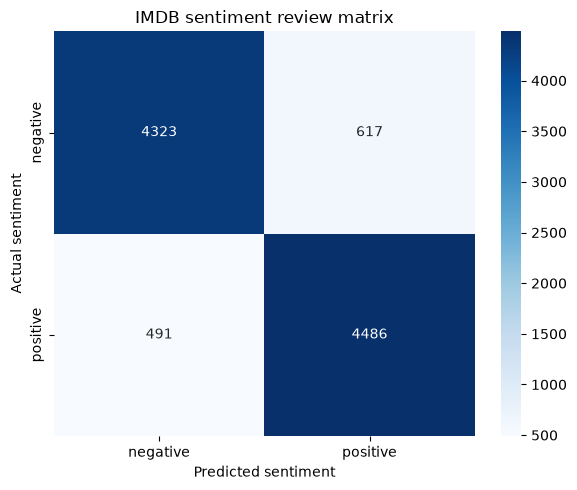

In [20]:
cm = confusion_matrix(y_test, y_pred, labels=["negative","positive"])

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt = "d",
    cmap= "Blues",
    xticklabels= ["negative","positive"],
    yticklabels=["negative","positive"]
    )

plt.xlabel("Predicted sentiment")
plt.ylabel("Actual sentiment")

plt.title("IMDB sentiment review matrix")
plt.tight_layout()
plt.show()


##### Error counts:

In [25]:

y_test_array = y_test.to_numpy() # convert the y_test series to a numpy array for easier indexing

negative_as_positive = np.where( (y_test_array == "negative") & (y_pred == "positive") )[0] # extract the indices of the samples that are negative but predicted as positive


positive_as_negative = np.where( (y_test_array == "positive") & (y_pred == "negative") )[0] # extract the indices of the samples that are positive but predicted as negative


print("==============================")
print("ERROR ANALYSIS")
print("==============================")

print("Negative predicted as positive (False Positive): ",  len(negative_as_positive))

print("Positive predicted as negative (False Negative): ",  len(positive_as_negative))

print("Total mistakes:" , len(negative_as_positive) + len(positive_as_negative))

ERROR ANALYSIS
Negative predicted as positive (False Positive):  617
Positive predicted as negative (False Negative):  491
Total mistakes: 1108


---

**Error Analysis**

The model made **1,108 incorrect predictions** on the test set.

- 617 negative reviews were predicted as positive.
- 491 positive reviews were predicted as negative.

The model therefore made slightly more false-positive sentiment predictions.

These errors may occur because TF-IDF focuses mainly on word importance and does not fully understand word order, sarcasm, mixed sentiment, or more complex contextual meaning.

---

#### `Model Comparison`: *(Sprint2/ 04_Transformers Distilbert vs Tf-idf)* `*smaple = 200*`

Since `Distilbert` was evaluated on a sample of 200, (in the previous weeks)        
TF-IDF should also be evaluated on those same 200 reviews for a fair small-sample comparison.       

In [26]:
X_200 = X_test.iloc[:200]
y_200 = y_test.iloc[:200]

X_200_tfidf = tfidf.transform(X_200)

y_200_pred = tfidf_model.predict(X_200_tfidf)

In [45]:
tfidf_200_accuracy  = accuracy_score(y_200, y_200_pred)

tfidf_200_precision = precision_score(y_200, y_200_pred, pos_label="positive")

tfidf_200_recall    = recall_score (y_200, y_200_pred, pos_label="positive")

tfidf_200_f1        = f1_score(y_200, y_200_pred, average="macro")

In [46]:
comparison = pd.DataFrame({
    "Model":[ "TF-IDF + Logistic Regression"  ,  "Distilbert"],
    "Accuracy":[tfidf_200_accuracy, 0.8600],
    "Macro_f1":[tfidf_200_f1, 0.8591],
    
})

In [47]:
print("\n==============================")
print("MODEL COMPARISON")
print("==============================")

print(comparison)


MODEL COMPARISON
                          Model  Accuracy  Macro_f1
0  TF-IDF + Logistic Regression     0.915  0.914828
1                    Distilbert     0.860  0.859100


--------------------

**Model Comparison**

The TF-IDF + Logistic Regression model was compared with the pretrained DistilBERT model from Sprint 2 using the same 200-review sample.

| Model | Accuracy | F1-score |
|---|---:|---:|
| TF-IDF + Logistic Regression | 0.915 | 0.911 |
| DistilBERT | 0.860 | 0.859 |

On this sample, TF-IDF + Logistic Regression achieved the better result, with an accuracy of **91.5%** compared with **86.0%** for DistilBERT.

One important difference is that the TF-IDF model was trained directly on the IMDb training data, while DistilBERT was used as a pretrained sentiment model without fine-tuning on this IMDb dataset.

Therefore, the result does not mean that TF-IDF is generally better than Transformers. It shows that, for this experiment, the simpler model adapted directly to the dataset performed better while also requiring less computation.


#### **`SHAP` Explainability**:

##### SHAP `Global` explainability

In [ ]:
# since logistic regression is a linear model 
# it is appropriate to use linear explainer
explainer = shap.LinearExplainer(tfidf_model , X_train_tfidf)

Background dataset has 39665 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=39665 when initializing the masker.


In [33]:
# we dont need to explain the whole test data,
# 200 samples are enough for visualization.
X_shap = X_test_tfidf[:200]

In [34]:
shap_values = explainer.shap_values(X_shap)

feature_names = tfidf.get_feature_names_out()

print("Shap values shape: ", np.array(shap_values).shape)

Shap values shape:  (200, 5000)


---

**Global SHAP Explainability**

SHAP was used to explain which TF-IDF features had the greatest influence on the Logistic Regression model.

The summary plot shows both the direction and strength of feature contributions,        
 while the bar plot shows the features with the highest average importance across the evaluated reviews.

This provides a global view of which words the model relies on most when separating positive and negative sentiment.

---

##### SHAP PLOTS:

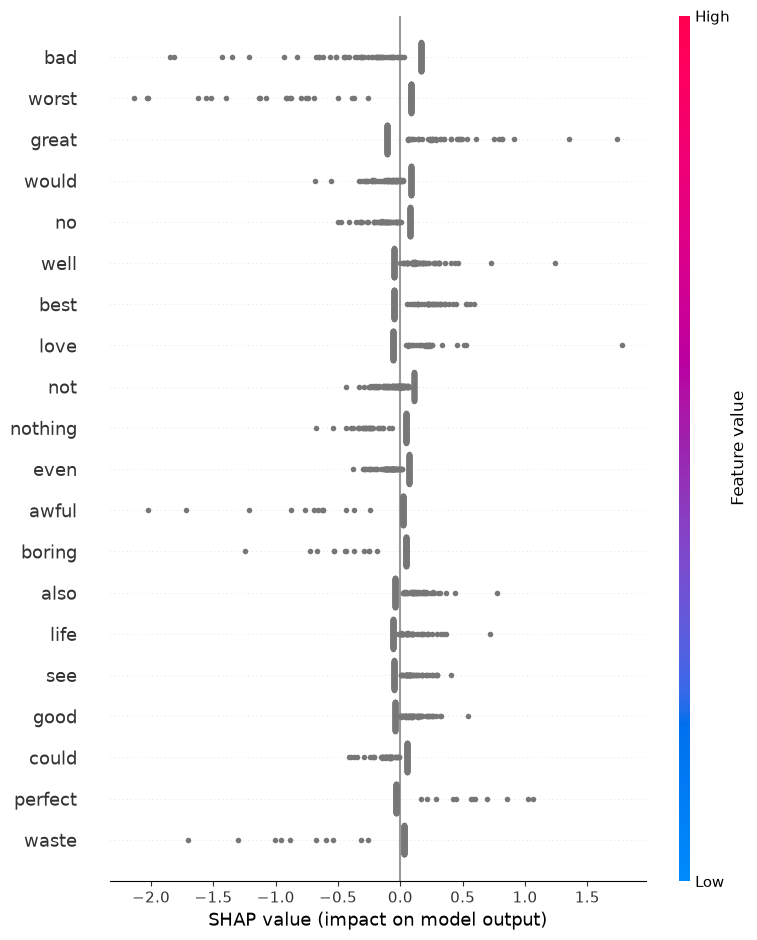

In [35]:
# global shap summary plot
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names
    )

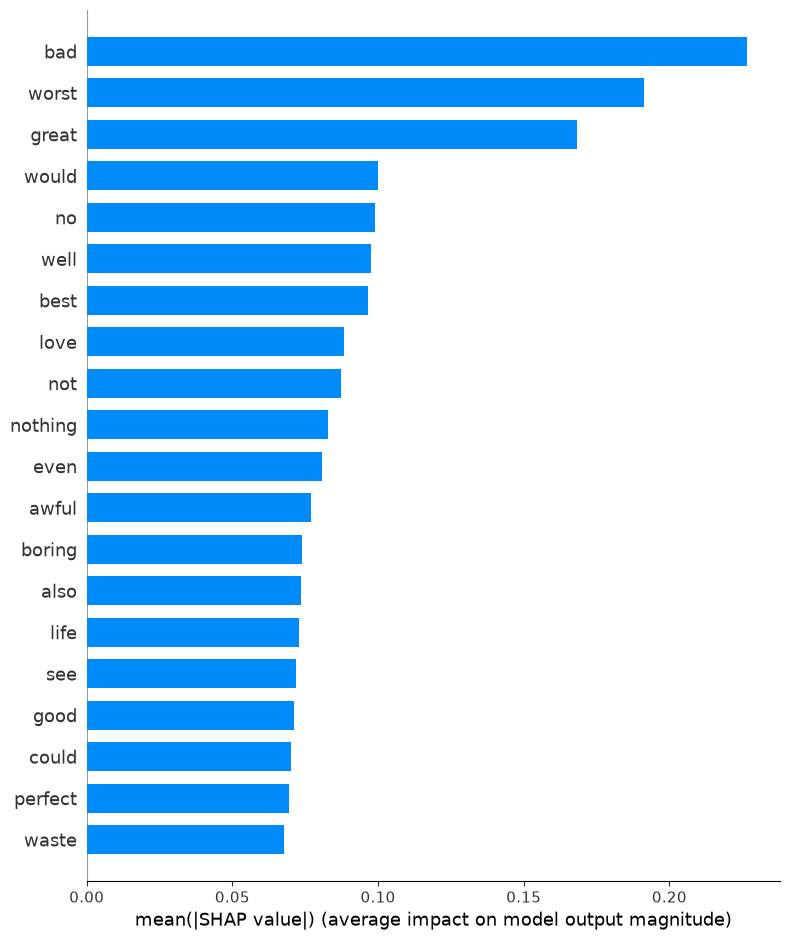

In [36]:
# global shap summary bar plot
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    plot_type = "bar"
    )

##### SHAP `INDIVISUAL` *prediction* explainability

In [ ]:
# prework info
index = 0

print("the indivisual review: \n", X_test.iloc[index]) 

print("\nActual sentiment:", y_test.iloc[index])

print("\nPredicted sentiment:", y_pred[index])

print("\nPositive Probability:", y_positive_prob[index])


the indivisual review: 
 wife watched dvr'ing encore action past week worst horror flick either u ever seen predictable dialogue wife guessing line spoken hokey special effect screenplay drifted place think part annoying stereotyping various character plot not mention gratuitous sex scene two young heroine movie neither real purpose bare certain part anatomy camera movie categorized comedy not horror villain movie spider stop motion animated not believable least ca n't say would done better job making film amateurish n't even `` b '' movie somewhere closer `` '' movie `` f '' possible think even science fiction 3000 would pas one

Actual sentiment: negative

Predicted sentiment: negative

Positive Probability: 0.013447899022146426


In [43]:
# convert sparse Tf-Idf row to dense
single_review = (X_test_tfidf[index].toarray()[0]) # the first transformed review

# Extract shap vlaues for this review
Single_shap_values = np.array(shap_values[index])

# get expected\base value
base_value = np.array(explainer.expected_value).reshape(-1)[0]

# create shap explanation object
explanation = shap.Explanation(
    
    values = Single_shap_values,
    base_values = base_value,
    data = single_review,
    feature_names = feature_names
)

- Waterfall plot explains WHY this particular prediction was made.    

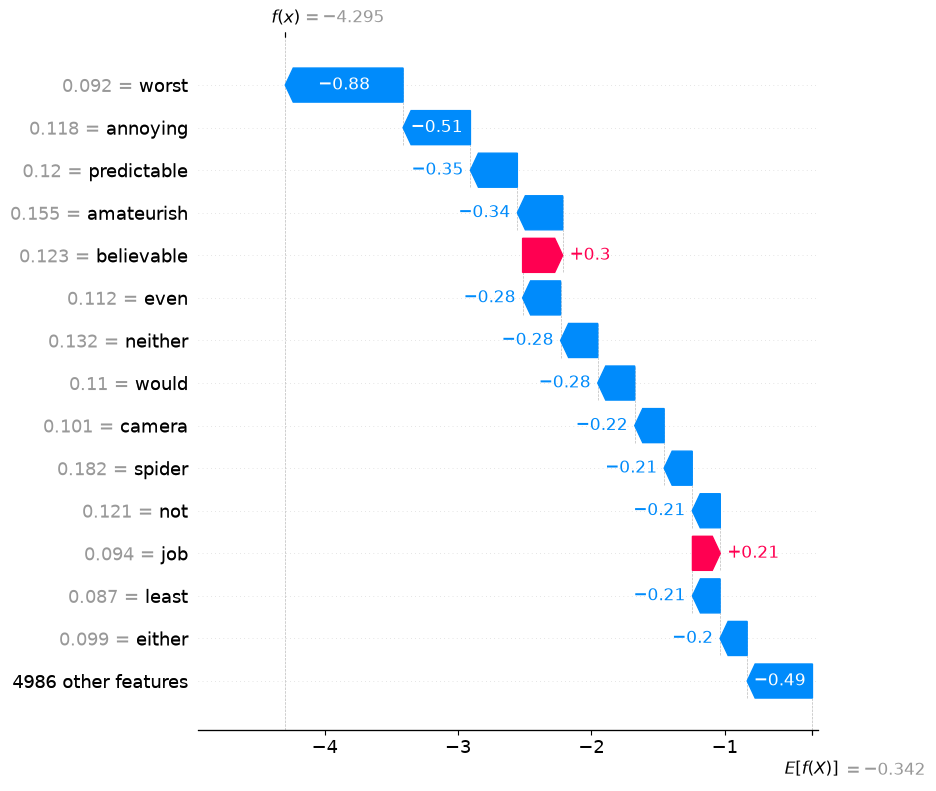

In [44]:
shap.plots.waterfall(
    explanation,
    max_display=15
)

---

 **Individual Prediction Explanation**

One individual review was examined using a SHAP waterfall plot.

The true label of the review was **negative**, and the model also predicted **negative**.       
 The predicted probability of the positive class was approximately **1.3%**,        
  meaning the model was highly confident in the negative prediction.

The waterfall plot shows how individual TF-IDF features pushed the prediction away from or toward the positive class, making the final decision easier to interpret.

---

### Sprint 3 Conclusion

During Sprint 3:        
-text preprocessing,        
--TF-IDF representation,        
---model integration,       
----full evaluation,        
-----error analysis,        
------SHAP explainability were applied to the IMDb sentiment-classification task.

The final TF-IDF + Logistic Regression model achieved approximately **88.8% accuracy** and **0.957 ROC-AUC** on the full test set.

On the same 200-review sample previously used for DistilBERT,  TF-IDF + Logistic Regression also achieved higher accuracy.

SHAP was then used to explain both the model's global feature importance and an individual prediction.

Overall, the sprint produced a complete and interpretable sentiment-classification workflow     
 that can now be prepared for deployment and final polishing later if needed.